# 04 — Predictive Modeling: Albania 2022 + Out-of-Sample

Compares the model zoo on the Albania 2022 cohort (repeated stratified CV, weighted) and runs the out-of-sample experiment (train 2009–2018 → test 2022).

**Reproducibility note.** scikit-learn (`libgomp`) and the gradient boosters (`libomp`) can abort a single process on macOS if both load together. So this notebook runs **scikit-learn models live in-kernel**, and **loads the booster CV rows** from the CSV produced by `scripts/run_model_comparison.py` (which runs boosters in their own process). The out-of-sample cell is lightweight and runs live.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.models.prepare import build_model_data
from src.models.experiment import compare_models_cv

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math')
print(data.meta)
print('Features:', data.feature_names)

2026-06-29 18:34:17 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.0


2026-06-29 18:34:17 [info     ] Removing correlated feature    feature=SES_COMPLETE threshold=0.97


2026-06-29 18:34:17 [info     ] Feature selection complete     n_features=20


2026-06-29 18:34:17 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_features=20 n_samples=6129 target_col=AT_RISK_MATH


{'domain': 'math', 'n_samples': 6129, 'n_features': 20, 'at_risk_rate': 0.7536, 'target_col': 'AT_RISK_MATH'}
Features: ['ESCS', 'HOMEPOS', 'GENDER', 'REPEAT', 'IMMIG', 'BELONG', 'TEACHSUP', 'ICTHOME', 'ICTSCH', 'ANXMAT', 'GRADE', 'HISCED', 'HISEI', 'MATERIAL_DEFICIT', 'DIGITAL_READINESS', 'DIGITAL_GAP', 'SES_x_ANXIETY', 'BELONG_x_TEACHSUP', 'GRADE_x_SES', 'GENDER_x_ANXMAT']


## 1. scikit-learn model comparison (live, 5×4 repeated stratified CV)

Weighted, leakage-safe (median imputation per fold). Boosters added in the next cell.

In [3]:
sklearn_models = ['logistic_regression','decision_tree','random_forest',
                  'extra_trees','gradient_boosting']
res_sklearn = compare_models_cv(data, sklearn_models, outer_folds=5, outer_repeats=4)
res_sklearn[['model','roc_auc_mean','roc_auc_std','pr_auc_mean','f1_macro_mean','mcc_mean']]

  [done] logistic_regression: AUC=0.7006 (5s)


2026-06-29 18:34:22 [info     ] Model compared                 auc=np.float64(0.7006) model=logistic_regression


  [done] decision_tree: AUC=0.5650 (1s)


2026-06-29 18:34:23 [info     ] Model compared                 auc=np.float64(0.565) model=decision_tree


  [done] random_forest: AUC=0.7021 (4s)


...

  [done] extra_trees: AUC=0.6937 (3s)


2026-06-29 18:34:30 [info     ] Model compared                 auc=np.float64(0.6937) model=extra_trees


  [done] gradient_boosting: AUC=0.7216 (29s)


2026-06-29 18:34:59 [info     ] Model compared                 auc=np.float64(0.7216) model=gradient_boosting


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_macro_mean,mcc_mean
0,gradient_boosting,0.7216,0.0126,0.8759,0.6012,0.2696
1,random_forest,0.7021,0.0130,0.8667,0.5877,0.2213
2,logistic_regression,0.7006,0.0156,0.8646,0.6074,0.2454
3,extra_trees,0.6937,0.0158,0.8618,0.5880,0.2138
4,decision_tree,0.5650,0.0124,0.7790,0.5625,0.1261


## 2. Full comparison incl. boosters

Booster rows come from `outputs/results/albania_2022_model_comparison.csv` (generated by `python scripts/run_model_comparison.py`). We display the merged master table.

In [4]:
full = pd.read_csv('../outputs/results/albania_2022_model_comparison.csv')
full[['model','roc_auc_mean','roc_auc_std','pr_auc_mean','f1_macro_mean','mcc_mean']]

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_macro_mean,mcc_mean
0,catboost,0.7244,0.0133,0.8751,0.6434,0.2953
1,gradient_boosting,0.7216,0.0126,0.8759,0.6012,0.2696
2,lightgbm,0.7105,0.0112,0.8692,0.6354,0.2773
3,random_forest,0.7021,0.0130,0.8667,0.5877,0.2213
4,logistic_regression,0.7006,0.0156,0.8646,0.6074,0.2454
5,extra_trees,0.6937,0.0158,0.8618,0.5880,0.2138
6,xgboost,0.6934,0.0111,0.8608,0.6060,0.2390
7,decision_tree,0.5650,0.0124,0.7790,0.5625,0.1261


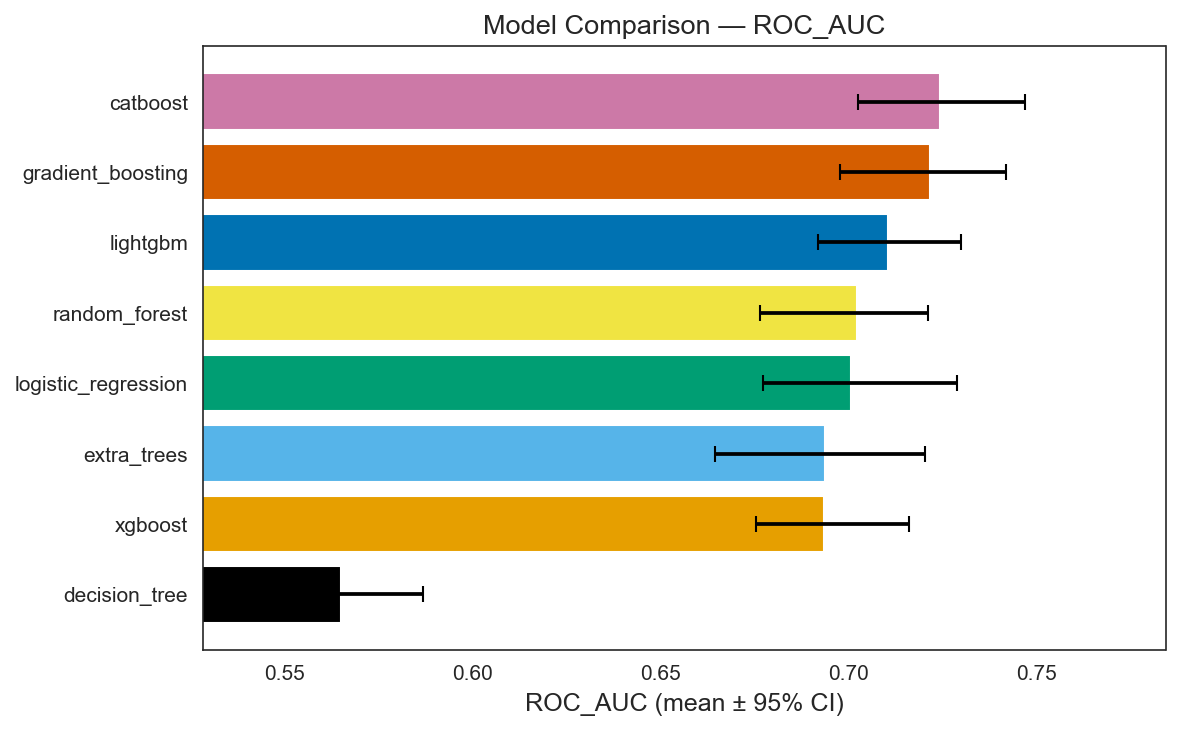

In [5]:
from src.visualization.model_plots import plot_cv_distribution
fig = plot_cv_distribution(full, metric='roc_auc'); plt.show()

**Reading:** CatBoost and Gradient Boosting lead (AUC ≈ 0.72); Logistic Regression is a strong, interpretable baseline (0.70). Decision Tree trails badly (0.57).

## 3. Out-of-sample experiment (train 2009–2018 → test 2022)

Tests whether models trained on the historical, improving period generalize to the 2022 crisis cohort. Lightweight (single fits) so it runs live; thread-limited for OpenMP safety.

In [6]:
from src.models.experiment import out_of_sample
long = pd.read_parquet('../data/processed/albania_longitudinal.parquet')
train = long[long.CYCLE.isin([2009,2012,2015,2018])]; test = long[long.CYCLE==2022]
oos_feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP','ANXMAT','GRADE','HISCED','HISEI']
# scikit-learn models live; boosters were added via the script (see JSON below)
res = out_of_sample(train, test, oos_feats,
                    ['logistic_regression','random_forest','extra_trees','gradient_boosting'],
                    domain='math')
pd.DataFrame({m: {'test_AUC': d['roc_auc']} for m, d in res['models'].items()}).T

2026-06-29 18:34:59 [info     ] Point target added             at_risk_rate=0.557 domain=math threshold=420.0


2026-06-29 18:34:59 [info     ] Feature selection complete     n_features=19


2026-06-29 18:34:59 [info     ] Model data built               at_risk_rate=0.5573 domain=math n_features=19 n_samples=20913 target_col=AT_RISK_MATH


2026-06-29 18:34:59 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.0


2026-06-29 18:34:59 [info     ] Removing correlated feature    feature=SES_COMPLETE threshold=0.97


...

  [oos] extra_trees: test_AUC=0.6618


2026-06-29 18:35:08 [info     ] OOS evaluated                  model=extra_trees test_auc=0.6618316369616427


  [oos] gradient_boosting: test_AUC=0.6735


2026-06-29 18:35:14 [info     ] OOS evaluated                  model=gradient_boosting test_auc=0.6734948076545337


,test_AUC
logistic_regression,0.6523
random_forest,0.6705
extra_trees,0.6618
gradient_boosting,0.6735


In [7]:
# Full OOS results (all 7 models) from the saved experiment JSON
import json
oos = json.load(open('../outputs/results/oos_2022_experiment.json'))
pd.DataFrame({m: {'test_AUC': d['roc_auc'], 'PR_AUC': d['pr_auc'], 'MCC': d['mcc']}
              for m, d in oos['models'].items()}).T.sort_values('test_AUC', ascending=False)

,test_AUC,PR_AUC,MCC
gradient_boosting,0.6735,0.8535,0.2067
random_forest,0.6705,0.8500,0.2088
lightgbm,0.6651,0.8486,0.1968
extra_trees,0.6618,0.8486,0.1983
catboost,0.6559,0.8430,0.1853
logistic_regression,0.6523,0.8413,0.1545
xgboost,0.6390,0.8322,0.1777


**Takeaway:** out-of-sample AUC falls to ~0.64–0.67 for every model. The covariate shift (notebook 03, detection AUC 0.98) is real and degrades transfer, but no model fully collapses — the 2022 risk structure shifted yet remains partly predictable from history.